In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

Production mix disaggregation

In [2]:
production_mix = pd.read_excel('./DH production mix/four_category.xlsx', sheet_name='agg')
production_mix.index = pd.to_datetime(production_mix['month'].astype(str).str.strip(), format='%Y-%m')
production_mix.drop(columns=['month'], inplace=True)

In [3]:
priority_sources = ['Waste heat', 'Electricity', 'Biomass', 'Fossil fuel']
years = range(2021, 2026)
daily_df = pd.DataFrame()

frames = []

for yr in years:
    daily = pd.read_csv(
        f'./DH production mix/daily_{yr}.csv',
        parse_dates=['date']
    )
    daily = daily.set_index('date')
    daily_df = pd.concat([daily_df, daily[priority_sources]])

    # Sum source columns + total per calendar month
    agg = daily[priority_sources + ['daily_total_mwh']].resample('ME').sum()
    frames.append(agg)

# production_disagg = pd.concat(frames)   # stack all years
# production_disagg.index.name = 'month'
# production_disagg.index = production_disagg.index.strftime('%Y-%m')
# production_disagg = production_disagg.rename(columns={'daily_total_mwh': 'monthly_total_mwh'})

display(daily_df.head())

,Waste heat,Electricity,Biomass,Fossil fuel
date,,,,
2021-01-01,1831.322581,162.580645,788.082089,742.342874
2021-01-02,1831.322581,162.580645,788.082089,416.767460
2021-01-03,1831.322581,162.580645,788.082089,1051.228698
2021-01-04,1831.322581,162.580645,788.082089,1095.905450
2021-01-05,1831.322581,162.580645,788.082089,1096.418976


In [4]:
production_mix = production_mix.apply(pd.to_numeric)
production_mix['monthly_total_mwh'] = production_mix.sum(axis=1)
production_mix.index = production_mix.index.strftime('%Y-%m')
display(production_mix.head())

,Waste heat,Electricity,Biomass,Fossil fuel,monthly_total_mwh
month,,,,,
2021-01,56771,5040,24228.0,26654,112693.0
2021-02,49186,4760,19487.0,20229,93662.0
2021-03,55311,401,13333.0,2577,71622.0
2021-04,49095,610,10910.0,1707,62322.0
2021-05,34248,418,756.0,3360,38782.0


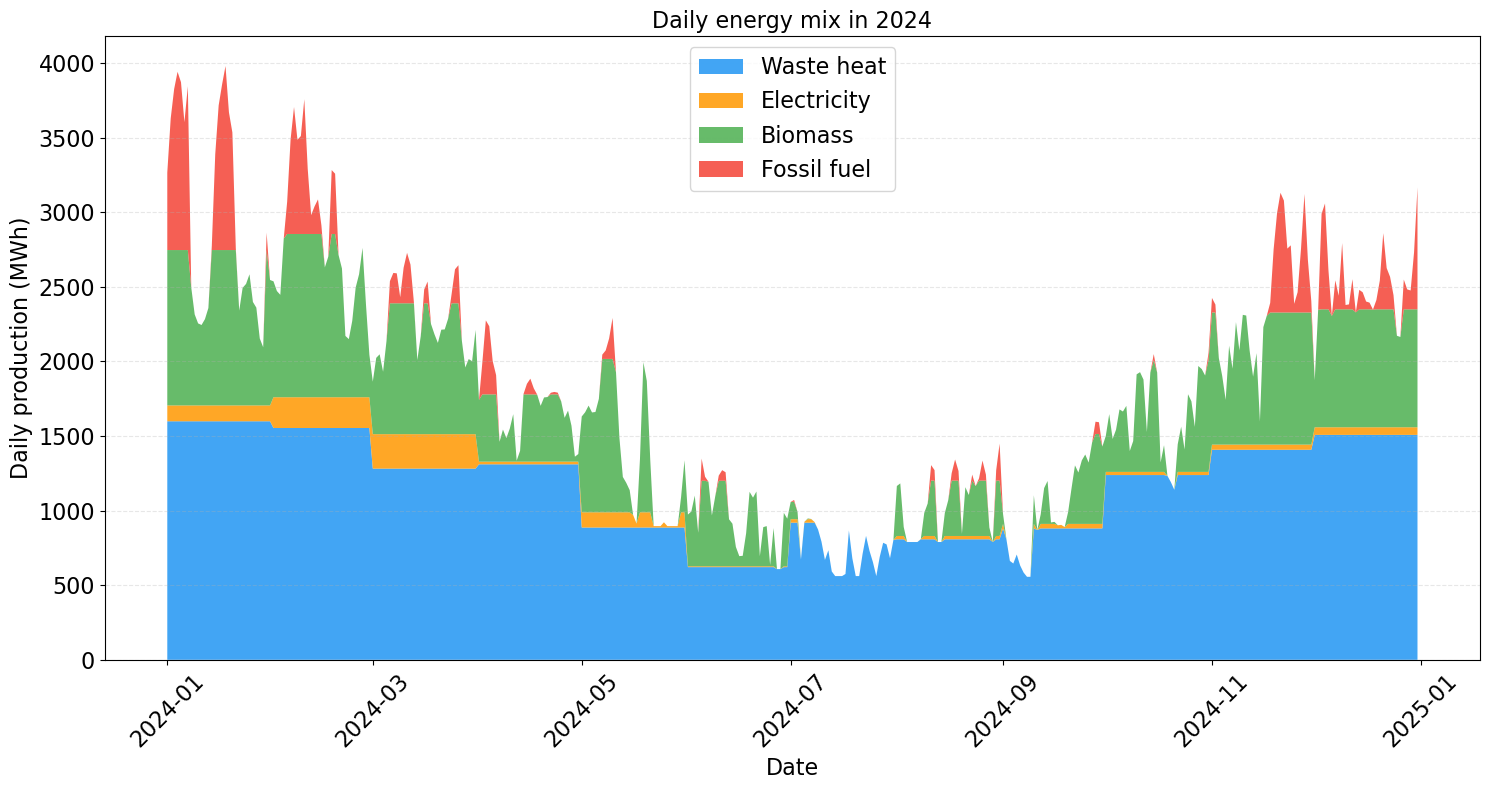

In [5]:
start_date = "2024-01-01"
end_date = "2024-12-31"

plot_df = daily_df[
    (daily_df.index >= start_date) &
    (daily_df.index <= end_date)
].copy()

energy_cols = ['Waste heat', 'Electricity', 'Biomass', 'Fossil fuel']
colors = ['#2196F3', '#FF9800', '#4CAF50', '#F44336']

plot_df['daily_total_mwh'] = plot_df.sum(axis=1)
plot_df['date_'] = plot_df.index
plot_df = plot_df.sort_values("date_")

plt.figure(figsize=(15, 8))

# Use stacked area plot for continuous daily composition with your colors
plt.stackplot(
    plot_df.index,
    [plot_df[col] for col in energy_cols],
    labels=energy_cols,
    colors=colors,            # <--- Pass your custom colors here
    alpha=0.85
)

# Plot a clean dashed line for the total daily production
# plt.plot(
#     plot_df.index,
#     plot_df["daily_total_mwh"],
#     color="black",
#     linestyle="--",
#     linewidth=1.2,
#     label="Total daily production"
# )

plt.xlabel("Date", fontsize=16)
plt.ylabel("Daily production (MWh)", fontsize=16)
plt.title(f"Daily energy mix in 2024", fontsize=16)
plt.yticks(fontsize=16)
plt.xticks(fontsize=16, rotation=45)
plt.legend(loc="best", fontsize=16)
plt.grid(True, axis="y", alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig("./figs/daily_stacked_area.png", dpi=300)
plt.show()

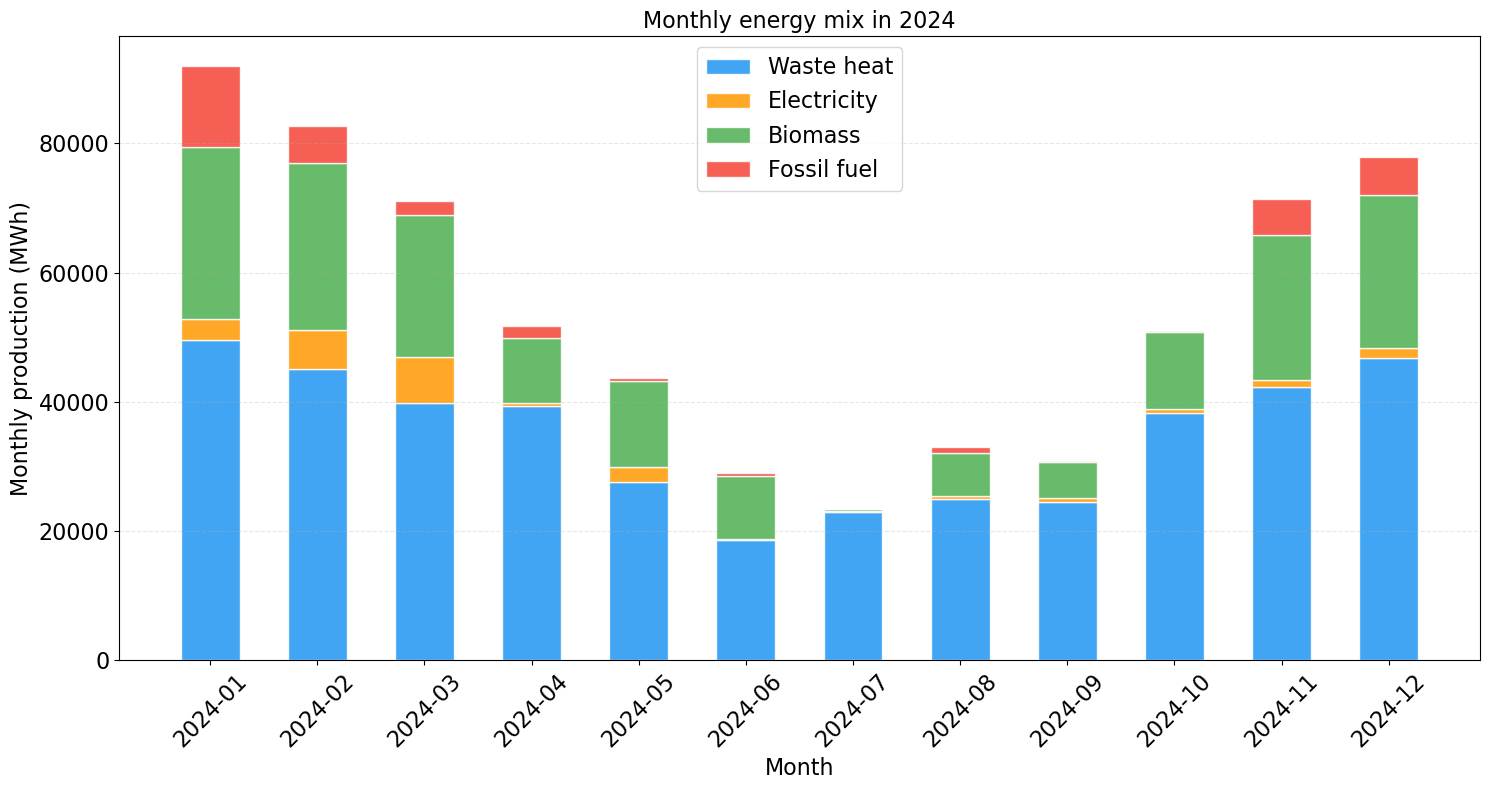

In [6]:
plot_df = production_mix[
    (production_mix.index >= start_date[:7]) &
    (production_mix.index <= end_date[:7])
].copy()

energy_cols = ['Waste heat', 'Electricity', 'Biomass', 'Fossil fuel']
colors = ['#2196F3', '#FF9800', '#4CAF50', '#F44336']

plt.figure(figsize=(15, 8))
bottom = np.zeros(len(plot_df))
for i, col in enumerate(energy_cols):
    plt.bar(
        plot_df.index,
        plot_df[col],
        bottom=bottom,
        label=col,
        color=colors[i],
        edgecolor='white',
        width=0.55,
        alpha=0.85
    )
    bottom += plot_df[col]
# Total line
# plt.plot(
#     plot_df.index,
#     plot_df['monthly_total_mwh'],
#     color='black',
#     linestyle='--',
#     marker='o',
#     linewidth=1.5,
#     label='Total monthly production'
# )
plt.xlabel('Month', fontsize=16)
plt.ylabel('Monthly production (MWh)', fontsize=16)
plt.title('Monthly energy mix in 2024', fontsize=16)
plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, axis='y', alpha=0.3, linestyle='--')
plt.legend(loc='best', fontsize=16)
plt.tight_layout()
plt.savefig('./figs/monthly_stacked_bar.png', dpi=300)

Results analysis

In [21]:
PRIORITY_SOURCES = ["Waste heat", "Electricity", "Biomass", "Fossil fuel"]
SOURCE_COLORS = {
    "Waste heat": "#2196F3",
    "Electricity": "#FF9800",
    "Biomass": "#4CAF50",
    "Fossil fuel": "#F44336",
}
SCENARIO_COLORS = {
    "Baseline (no TES/DSM)": "#E57373",
    "Water Tank + DSM": "#64B5F6",
    "PCM Storage + DSM": "#81C784",
}
SCENARIO_SHORT = {
    "Baseline (no TES/DSM)": "Baseline",
    "Water Tank + DSM": "Water Tank",
    "PCM Storage + DSM": "PCM",
}


In [22]:
RESULTS_DIR = "./simulation/results/"
FIGS_DIR = "./figs"

def load_results():
    """Load all scenario results."""
    scenarios = {}
    for fname, label in [
        ("baseline_results.csv", "Baseline (no TES/DSM)"),
        ("water_tank_results.csv", "Water Tank + DSM"),
        ("pcm_storage_results.csv", "PCM Storage + DSM"),
    ]:
        path = RESULTS_DIR + fname
        df = pd.read_csv(path, parse_dates=["date"])
        scenarios[label] = df
    return scenarios

scenarios = load_results()

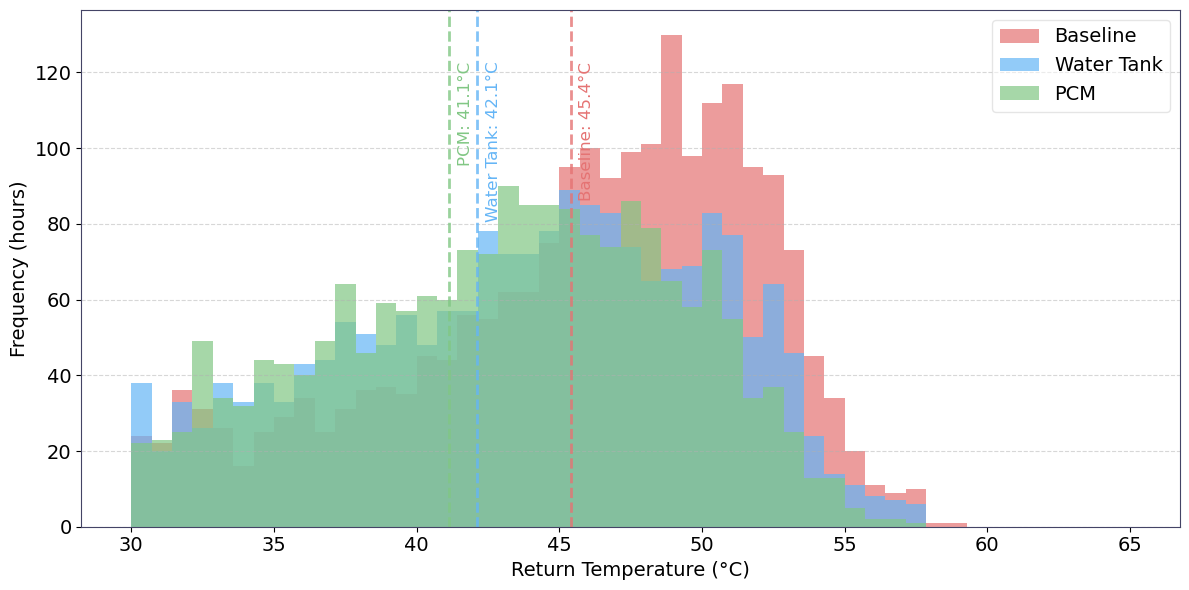

  ✓ Return temperature distribution


In [38]:
def plot_return_temperature_distribution(scenarios: dict):
    """Histogram of return temperatures."""
    fig, ax = plt.subplots(figsize=(12, 6))
    # fig.patch.set_facecolor("#1a1a2e")
    # ax.set_facecolor("#16213e")

    bins = np.linspace(30, 65, 50)

    for name, df in scenarios.items():
        ax.hist(df["T_return_primary"].values, bins=bins,
                color=SCENARIO_COLORS.get(name),
                alpha=0.7, label=SCENARIO_SHORT.get(name, name),
                linewidth=0.3)

    # Add vertical lines for means
    for name, df in scenarios.items():
        mean_t = df["T_return_primary"].mean()
        ax.axvline(mean_t, color=SCENARIO_COLORS.get(name, "white"),
                   linestyle="--", linewidth=2, alpha=0.8)
        ax.text(mean_t + 0.3, ax.get_ylim()[1] * 0.9,
                f"{SCENARIO_SHORT.get(name, name)}: {mean_t:.1f}°C",
                color=SCENARIO_COLORS.get(name, "white"), fontsize=12,
                rotation=90, va="top")

    ax.set_xlabel("Return Temperature (°C)", fontsize=14)
    ax.set_ylabel("Frequency (hours)", fontsize=14)
    # ax.set_title("Primary Return Temperature Distribution", fontsize=14, pad=12)
    ax.legend(fontsize=14, framealpha=0.5)
    plt.yticks(fontsize=14)
    plt.xticks(fontsize=14)
    for spine in ax.spines.values():
        spine.set_color("#444466")
    ax.grid(True, axis="y", linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig("./figs/return_temp_distribution.png", dpi=300)
    plt.show()
    plt.close(fig)
    print("  ✓ Return temperature distribution")

plot_return_temperature_distribution(scenarios)

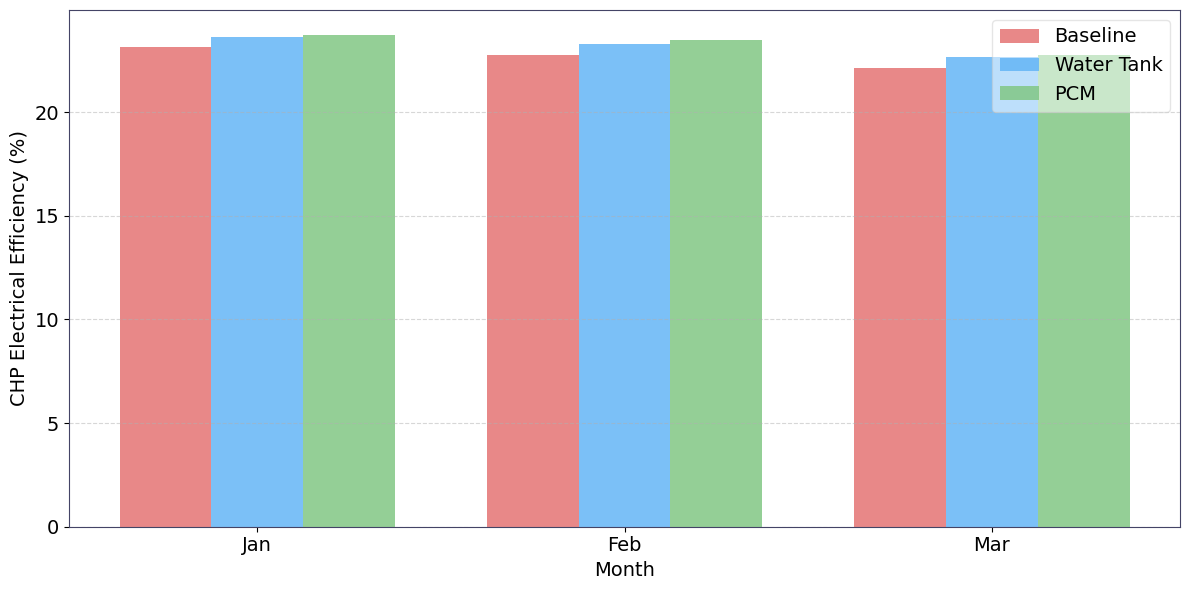

  ✓ CHP efficiency


In [37]:
def plot_chp_efficiency(scenarios: dict):
    """Monthly average CHP electrical efficiency comparison."""
    fig, ax = plt.subplots(figsize=(12, 6))
    # Light/white background matches the return temperature plot style

    month_labels = ["Jan", "Feb", "Mar"]
    width = 0.25
    x = np.arange(1, 4)

    for i, (name, df) in enumerate(scenarios.items()):
        df_copy = df.copy()
        df_copy["month"] = df_copy["date"].dt.month
        monthly_eta = df_copy.groupby("month")["eta_el_chp"].mean()
        vals = [monthly_eta.get(m, 0) * 100 for m in x]  # Convert to %

        # Position adjustment handles 3 scenarios centered around the tick
        ax.bar(x + (i - 1) * width, vals, width=width,
               color=SCENARIO_COLORS.get(name),
               label=SCENARIO_SHORT.get(name, name),
               alpha=0.85, linewidth=0.3)  # Matches alpha=0.5 and linewidth=0.3

    ax.set_xlabel("Month", fontsize=14)
    ax.set_ylabel("CHP Electrical Efficiency (%)", fontsize=14)
    # Title removed to match your paper's distribution plot configuration
    
    ax.set_xticks(x)
    ax.set_xticklabels(month_labels)
    ax.legend(fontsize=14, framealpha=0.5)
    plt.yticks(fontsize=14)
    plt.xticks(fontsize=14)
    
    for spine in ax.spines.values():
        spine.set_color("#444466")
        
    ax.grid(True, axis="y", linestyle='--', alpha=0.5)

    plt.tight_layout()
    # Updated to save with a clean background and use standard string paths
    plt.savefig("./figs/chp_efficiency_monthly.png", dpi=300)
    plt.show()
    plt.close(fig)
    print("  ✓ CHP efficiency")

plot_chp_efficiency(scenarios)